In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 6, "cos": 6}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.277140, valid=0.198043, test=0.194371
	validation loss decreased (inf -> 0.198043), saving model ...
	epoch 2 losses: train=0.569798, valid=0.156426, test=0.152594
	validation loss decreased (0.198043 -> 0.156426), saving model ...
	epoch 3 losses: train=0.550464, valid=0.149585, test=0.145339
	validation loss decreased (0.156426 -> 0.149585), saving model ...
	epoch 4 losses: train=0.540420, valid=0.147064, test=0.142731
	validation loss decreased (0.149585 -> 0.147064), saving model ...
	epoch 5 losses: train=0.490444, valid=0.115164, test=0.110912
	validation loss decreased (0.147064 -> 0.115164), saving model ...
	epoch 6 losses: train=0.163671, valid=0.032191, test=0.031939
	validation loss decreased (0.115164 -> 0.032191), saving model ...
	epoch 7 losses: train=0.095252, valid=0.028557, test=0.027729
	validation loss decreased (0.032191 -> 0.028557), saving model ...
	epoch 8 losses: train=0.085846, valid=0.025848, test=0.02

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

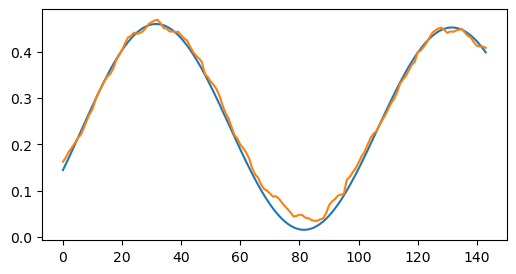

In [7]:
jdata = 17

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [8]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.447324, valid=-0.079835, test=-0.079143
	validation loss decreased (inf -> -0.079835), saving model ...
	epoch 2 losses: train=-0.044827, valid=-0.133982, test=-0.135729
	validation loss decreased (-0.079835 -> -0.133982), saving model ...
	epoch 3 losses: train=-0.122239, valid=-0.112976, test=-0.121662
	early stopping counter: 1 out of 10
	epoch 4 losses: train=-0.183359, valid=0.329077, test=0.232473
	early stopping counter: 2 out of 10
	epoch 5 losses: train=-0.232769, valid=0.362504, test=0.349640
	early stopping counter: 3 out of 10
	epoch 6 losses: train=-0.265796, valid=0.692739, test=0.625289
	early stopping counter: 4 out of 10
	epoch 7 losses: train=-0.289887, valid=0.604432, test=0.585695
	early stopping counter: 5 out of 10
	epoch 8 losses: train=-0.308725, valid=0.633401, test=0.591331
	early stopping counter: 6 out of 10
	epoch 9 losses: train=-0.327699, valid=0.500151, test=0.497590
	early stopping counter: 7

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

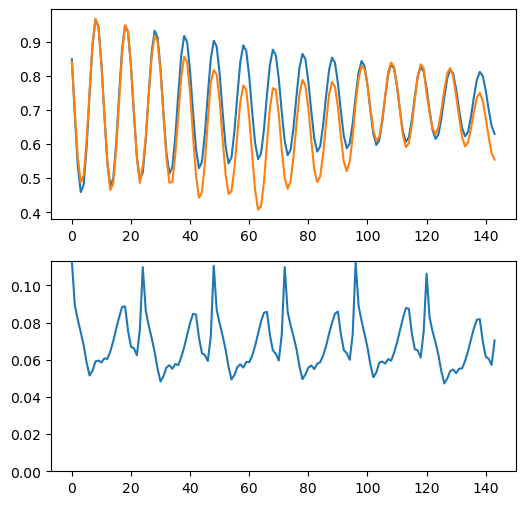

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [11]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.287665, valid=0.306413, test=0.294495
	validation loss decreased (inf -> 0.306413), saving model ...
	epoch 2 losses: train=0.698969, valid=0.250852, test=0.239134
	validation loss decreased (0.306413 -> 0.250852), saving model ...
	epoch 3 losses: train=0.645161, valid=0.239376, test=0.229281
	validation loss decreased (0.250852 -> 0.239376), saving model ...
	epoch 4 losses: train=0.609973, valid=0.223621, test=0.214493
	validation loss decreased (0.239376 -> 0.223621), saving model ...
	epoch 5 losses: train=0.586245, valid=0.218418, test=0.209317
	validation loss decreased (0.223621 -> 0.218418), saving model ...
	epoch 6 losses: train=0.503989, valid=0.154124, test=0.148336
	validation loss decreased (0.218418 -> 0.154124), saving model ...
	epoch 7 losses: train=0.315470, valid=0.092052, test=0.089324
	validation loss decreased (0.154124 -> 0.092052), saving model ...
	epoch 8 losses: train=0.185726, valid=0.058545, test=0.056

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

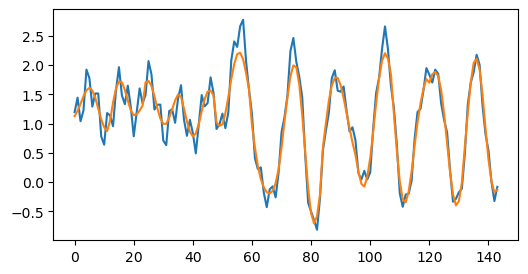

In [13]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [14]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.032001, valid=-0.131491, test=-0.133684
	validation loss decreased (inf -> -0.131491), saving model ...
	epoch 2 losses: train=-0.448398, valid=0.055789, test=0.061954
	early stopping counter: 1 out of 10
	epoch 3 losses: train=-0.535898, valid=0.151863, test=0.155446
	early stopping counter: 2 out of 10
	epoch 4 losses: train=-0.577906, valid=-0.077096, test=-0.071390
	early stopping counter: 3 out of 10
	epoch 5 losses: train=-0.622682, valid=0.203111, test=0.184272
	early stopping counter: 4 out of 10
	epoch 6 losses: train=-0.658486, valid=-0.058752, test=-0.033905
	early stopping counter: 5 out of 10
	epoch 7 losses: train=-0.686456, valid=0.540563, test=0.460590
	early stopping counter: 6 out of 10
	epoch 8 losses: train=-0.726887, valid=0.040238, test=0.058327
	early stopping counter: 7 out of 10
	epoch 9 losses: train=-0.757387, valid=-0.017078, test=0.008935
	early stopping counter: 8 out of 10
	epoch 10 losses: trai

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

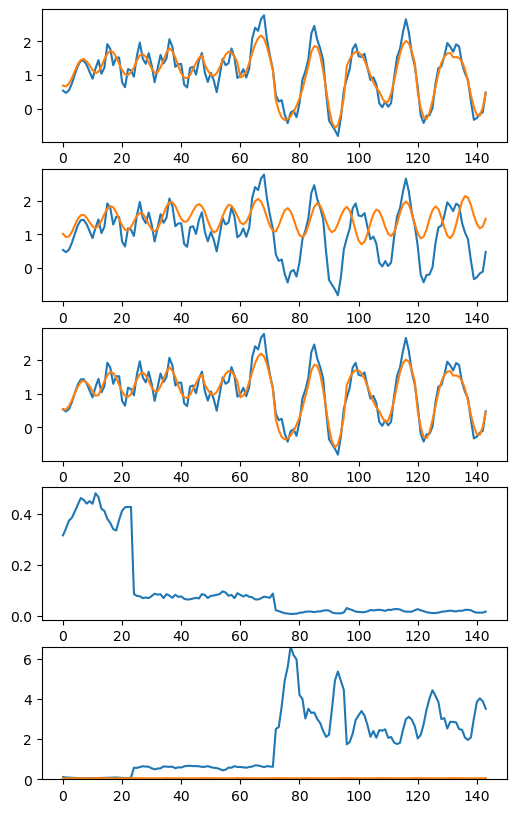

In [22]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break